In [1]:
import numpy as np
import matplotlib.pyplot as plt
import shutil, os
from scipy import integrate, optimize, special

fontsi  = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size':         fontsi,
    'axes.titlesize':    fontsi2,
    'axes.labelsize':    fontsi2 - 1,
    'xtick.labelsize':   fontsi,
    'ytick.labelsize':   fontsi,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'legend.frameon':    False,
    'figure.dpi':        130,
})
os.makedirs('sheet6_output', exist_ok=True)
C_BLUE   = '#1f4e79'
C_ORANGE = '#8c2d19'
C_GREEN  = '#2d6a4f'
C_GRAY   = '#6c757d'
C_RED    = '#c0392b'

# 6.1 Bayesian evidence in the Laplace approximation

Show explicitly how the Bayesian evidence penalises model complexity using the Laplace approximation. Let the evidence for a model with parameter vector $\boldsymbol{\theta} \in \mathbb{R}^d$ be

$$
Z = p(\boldsymbol{x}) = \int \mathcal{L}(\boldsymbol{\theta})\, \pi(\boldsymbol{\theta})\, \mathrm{d}^d\theta.
$$

Assume that the posterior is sharply peaked and can be approximated near its mode $\boldsymbol{\theta}_*$ by a Gaussian obtained from a second-order Taylor expansion of the log posterior (as in the lecture). Let

$$
\boldsymbol{H} = -\left. \nabla_{\theta}\nabla_{\theta} \ln p(\boldsymbol{\theta}\mid \boldsymbol{x}) \right|_{\boldsymbol{\theta}_*},
\qquad
\boldsymbol{C} = \boldsymbol{H}^{-1}.
$$

Assume also that the prior is flat over a parameter-space volume $V_\pi$, so that $\pi(\boldsymbol{\theta}) = 1/V_\pi$ within that volume, and in particular $\pi(\boldsymbol{\theta}_*) = 1/V_\pi$.

**a.** Expand $\ln p(\boldsymbol{\theta}\mid \boldsymbol{x})$ to second order around $\boldsymbol{\theta}_*$, and show that the posterior is approximated by a multivariate Gaussian with covariance matrix $\boldsymbol{C}$.

**b.** Use this Gaussian approximation to evaluate the evidence integral and show that
$$Z \simeq \mathcal{L}(\boldsymbol{\theta}_*) \, \frac{(2\pi)^{d/2} \det(\boldsymbol{C})^{1/2}}{V_\pi}.$$

**c.** Now assume a regular model in the large-sample limit, so that the Hessian scales as $\boldsymbol{H} \propto n$, where $n$ is the number of data points. Show that this implies
$$\det(\boldsymbol{C})^{1/2} \propto n^{-d/2}.$$

**d.** Now prove that, for large $n$,
$$-2 \ln Z \;\to\; -2 \ln \mathcal{L}(\boldsymbol{\theta}_*) + d \ln n + \text{terms independent of } n.$$
Interpret this result as the Bayesian information criterion, and explain why each additional parameter contributes a complexity penalty of $\ln n$.

---

## Solution

### Part a

At the mode $\boldsymbol{\theta}_*$ the gradient of $\ln p(\boldsymbol{\theta}|\boldsymbol{x})$ vanishes by definition. The second-order Taylor expansion therefore reads

$$
\ln p(\boldsymbol{\theta}|\boldsymbol{x})
\approx \ln p(\boldsymbol{\theta}_*|\boldsymbol{x})
  - \tfrac{1}{2}(\boldsymbol{\theta}-\boldsymbol{\theta}_*)^\top
    \boldsymbol{H}\,(\boldsymbol{\theta}-\boldsymbol{\theta}_*).
$$

Exponentiating:

$$
p(\boldsymbol{\theta}|\boldsymbol{x})
\approx p(\boldsymbol{\theta}_*|\boldsymbol{x})
  \exp\!\left(-\tfrac{1}{2}(\boldsymbol{\theta}-\boldsymbol{\theta}_*)^\top
    \boldsymbol{H}\,(\boldsymbol{\theta}-\boldsymbol{\theta}_*)\right),
$$

which is proportional to $\mathcal{N}(\boldsymbol{\theta}_*,\boldsymbol{C})$ with $\boldsymbol{C}=\boldsymbol{H}^{-1}$. $\square$

### Part b

The same Taylor expansion applies to the log of the integrand $\mathcal{L}(\boldsymbol{\theta})\pi(\boldsymbol{\theta})$. For a flat prior, $\ln\pi$ contributes no curvature, so the Hessian of $\ln[\mathcal{L}\pi]$ at $\boldsymbol{\theta}_*$ equals the Hessian of $\ln p(\boldsymbol{\theta}|\boldsymbol{x})$, which is $-\boldsymbol{H}$ by definition. Hence:

$$
\mathcal{L}(\boldsymbol{\theta})\,\pi(\boldsymbol{\theta})
\;\approx\;
\mathcal{L}(\boldsymbol{\theta}_*)\,\pi(\boldsymbol{\theta}_*)
\exp\!\left(-\tfrac{1}{2}(\boldsymbol{\theta}-\boldsymbol{\theta}_*)^\top\boldsymbol{H}\,(\boldsymbol{\theta}-\boldsymbol{\theta}_*)\right).
$$

Substituting $\boldsymbol{\delta} = \boldsymbol{\theta} - \boldsymbol{\theta}_*$ and pulling the constant prefactor outside:

$$
Z \approx \mathcal{L}(\boldsymbol{\theta}_*)\,\pi(\boldsymbol{\theta}_*)
\underbrace{\int_{\mathbb{R}^d}
  \exp\!\left(-\tfrac{1}{2}\,\boldsymbol{\delta}^\top\boldsymbol{H}\,\boldsymbol{\delta}\right)
  \mathrm{d}^d\delta}_{I}.
$$

**Evaluating $I$.** Since $\boldsymbol{H}$ is real symmetric positive-definite it admits an eigendecomposition $\boldsymbol{H} = \boldsymbol{O}^\top\boldsymbol{\Lambda}\boldsymbol{O}$, where $\boldsymbol{O}$ is orthogonal and $\boldsymbol{\Lambda}=\mathrm{diag}(\lambda_1,\ldots,\lambda_d)$ with $\lambda_i>0$. Change variables to $\boldsymbol{u}=\boldsymbol{O}\boldsymbol{\delta}$; since $|\det\boldsymbol{O}|=1$ the volume element is unchanged ($\mathrm{d}^d\delta = \mathrm{d}^d u$), and $\boldsymbol{\delta}^\top\boldsymbol{H}\boldsymbol{\delta} = \boldsymbol{u}^\top\boldsymbol{\Lambda}\boldsymbol{u} = \sum_{i=1}^d \lambda_i u_i^2$. The integral therefore factorises:

$$
I = \int_{\mathbb{R}^d} e^{-\frac{1}{2}\sum_i \lambda_i u_i^2}\,\mathrm{d}^d u
  = \prod_{i=1}^{d}\int_{-\infty}^{\infty} e^{-\frac{1}{2}\lambda_i u_i^2}\,\mathrm{d}u_i
  = \prod_{i=1}^{d}\sqrt{\frac{2\pi}{\lambda_i}}
  = (2\pi)^{d/2}\prod_{i=1}^{d}\lambda_i^{-1/2}.
$$

Because $\prod_i \lambda_i = \det\boldsymbol{\Lambda} = \det\boldsymbol{H}$ and $\det(\boldsymbol{C}) = (\det\boldsymbol{H})^{-1}$:

$$
I = (2\pi)^{d/2}(\det\boldsymbol{H})^{-1/2} = (2\pi)^{d/2}\det(\boldsymbol{C})^{1/2}.
$$

Inserting $\pi(\boldsymbol{\theta}_*)=1/V_\pi$:

$$
{Z \simeq \mathcal{L}(\boldsymbol{\theta}_*)\,
  \frac{(2\pi)^{d/2}\det(\boldsymbol{C})^{1/2}}{V_\pi}.} 
$$

### Part c

If $\boldsymbol{H} = n\,\boldsymbol{H}_0$ for a fixed positive-definite matrix $\boldsymbol{H}_0$, then $\boldsymbol{C}=n^{-1}\boldsymbol{H}_0^{-1}$, so

$$
\det(\boldsymbol{C}) = n^{-d}\det(\boldsymbol{H}_0^{-1}),
\qquad
\det(\boldsymbol{C})^{1/2} = \frac{\det(\boldsymbol{H}_0^{-1})^{1/2}}{n^{d/2}} \propto n^{-d/2}. 
$$

### Part d

Taking $-2\ln$ of the result from (b) and inserting $\det(\boldsymbol{C})^{1/2}\propto n^{-d/2}$ from (c):

$$
\ln Z \simeq \ln\mathcal{L}(\boldsymbol{\theta}_*)
  + \tfrac{d}{2}\ln(2\pi)
  + \underbrace{\tfrac{1}{2}\ln\det(\boldsymbol{C})}_{=-\frac{d}{2}\ln n+\mathrm{const}}
  - \ln V_\pi,
$$

so

$$
{-2\ln Z \;\to\; -2\ln\mathcal{L}(\boldsymbol{\theta}_*) + d\ln n
  + \text{terms independent of }n.}
$$

This is the **Bayesian information criterion (BIC)**. The $+\ln n$ penalty per parameter arises because the posterior volume $V_{\mathrm{post}}\propto n^{-d/2}$ shrinks as more data accumulate while the prior volume $V_\pi$ stays fixed. The ratio $V_{\mathrm{post}}/V_\pi \propto n^{-d/2}$ measures the wasted prior space; $-2\ln$ of one factor $n^{-1/2}$ per parameter gives $+\ln n$ per parameter. $\square$

# 6.2 Inversion transformation sampling

We would like to produce a random sample $\{x_i\}$ drawn from the probability distribution function

$$
p(x) = \frac{1}{Z}\, x^2 e^{-x^2/2}, \qquad x \ge 0,
$$

and $p(x)=0$ for $x<0$, where $Z$ is the normalisation constant.

**a.** Show that $p(x)$ is normalised on $[0,\infty)$ by determining the normalisation constant $Z$.

**b.** Compute the cumulative distribution function
$$F(x) = \int_0^x p(t)\,dt.$$
Show that the resulting expression cannot be inverted in closed form to obtain $x = F^{-1}(u)$ analytically.

**c.** Use a numerical root-finding method to generate samples from this distribution with the inverse transform method. In other words, for each uniform random number $u \in [0,1)$, solve $F(x) = u$ numerically for $x$.

**d.** Write a program to generate $N = 10^6$ random numbers distributed according to $p(x)$ using your numerical inversion method and plot a histogram of the generated sample comparing it with the analytic PDF.

---

## Solution

### Part a

Substitute $t = x^2/2$, so $x = \sqrt{2t}$ and $dx = dt/\sqrt{2t}$:

$$
Z = \int_0^\infty x^2 e^{-x^2/2}\,dx
  = \int_0^\infty 2t\,e^{-t}\frac{dt}{\sqrt{2t}}
  = \sqrt{2}\int_0^\infty t^{1/2}e^{-t}\,dt
  = \sqrt{2}\,\Gamma\!\left(\tfrac{3}{2}\right)
  = \sqrt{2}\cdot\frac{\sqrt{\pi}}{2}
  = \sqrt{\frac{\pi}{2}}.
$$

Hence $p(x) = \sqrt{2/\pi}\,x^2 e^{-x^2/2}$ — the **Maxwell speed distribution**. $\square$

### Part b

Integrate by parts with $u = t$, $dv = te^{-t^2/2}\,dt$ (so $v = -e^{-t^2/2}$):

$$
\int_0^x t^2 e^{-t^2/2}\,dt
= \Bigl[-t\,e^{-t^2/2}\Bigr]_0^x + \int_0^x e^{-t^2/2}\,dt
= -x\,e^{-x^2/2} + \sqrt{\frac{\pi}{2}}\,\mathrm{erf}\!\left(\frac{x}{\sqrt{2}}\right).
$$

Dividing by $Z = \sqrt{\pi/2}$:

$$
{F(x) = \mathrm{erf}\!\left(\frac{x}{\sqrt{2}}\right)
      - \sqrt{\frac{2}{\pi}}\,x\,e^{-x^2/2}.}
$$

**Check:** $F'(x)=\sqrt{2/\pi}\,e^{-x^2/2}-\sqrt{2/\pi}(1-x^2)e^{-x^2/2}=\sqrt{2/\pi}\,x^2e^{-x^2/2}=p(x)$ ✓; $F(0)=0$ ✓; $F(\infty)=1$ ✓.

The equation $F(x)=u$ mixes $\mathrm{erf}(x/\sqrt{2})$ with $xe^{-x^2/2}$; no algebraic manipulation can isolate $x$, so $F^{-1}(u)$ has no closed form. $\square$

### Parts c & d — see code cell below

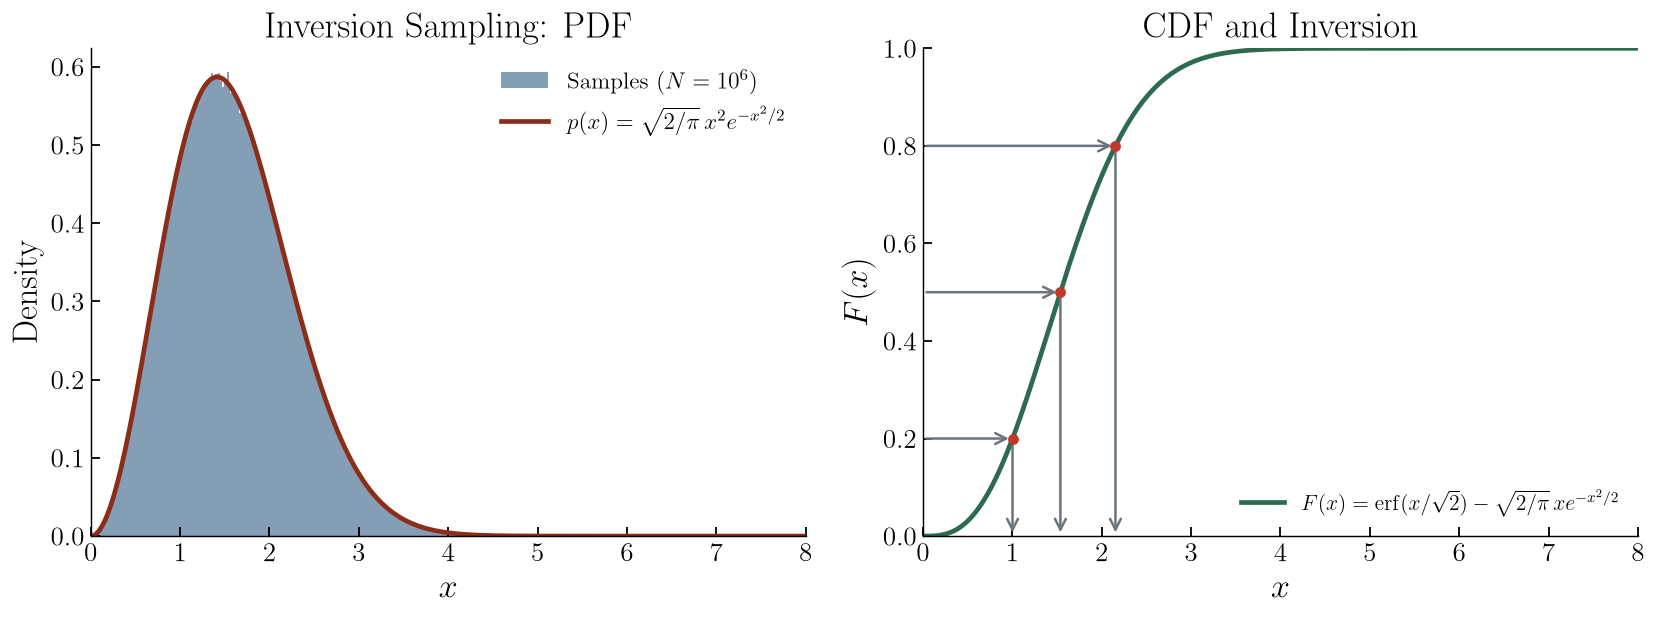

Sample mean: 1.59590  (analytic 2*sqrt(2/pi) = 1.59577)
Sample std:  0.67346  (analytic sqrt(3-8/pi) = 0.67344)


In [2]:
# 6.2 c,d: numerical inversion sampling via lookup table
# Build a dense grid (x, F(x)) and invert by linear interpolation.

Z_norm = np.sqrt(np.pi / 2.0)

def pdf_maxwell(x):
    return x**2 * np.exp(-x**2 / 2.0) / Z_norm

def cdf_maxwell(x):
    return special.erf(x / np.sqrt(2.0)) - np.sqrt(2.0 / np.pi) * x * np.exp(-x**2 / 2.0)

# Verify analytic CDF against quadrature
check_x = 3.0
cdf_quad, _ = integrate.quad(pdf_maxwell, 0, check_x)

# Lookup table: F is monotonically increasing on [0, 15]
x_grid   = np.linspace(0.0, 15.0, 50_000)
cdf_grid = cdf_maxwell(x_grid)

rng = np.random.default_rng(42)
N   = 1_000_000
u   = rng.uniform(0.0, 1.0, N)
x_samples = np.interp(u, cdf_grid, x_grid)   # invert F numerically
#



x_plot = np.linspace(0, 8, 800)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(x_samples, bins=300, density=True,
        color=C_BLUE, alpha=0.55, label=r'Samples ($N=10^6$)')
ax.plot(x_plot, pdf_maxwell(x_plot), lw=2.6, color=C_ORANGE,
        label=r'$p(x)=\sqrt{2/\pi}\,x^2 e^{-x^2/2}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Density')
ax.set_xlim(0, 8)
ax.set_title('Inversion Sampling: PDF')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)

ax2 = axes[1]
ax2.plot(x_plot, cdf_maxwell(x_plot), lw=2.6, color=C_GREEN,
         label=r'$F(x)=\mathrm{erf}(x/\sqrt{2})-\sqrt{2/\pi}\,xe^{-x^2/2}$')
for u_ex in [0.2, 0.5, 0.8]:
    x_ex = float(np.interp(u_ex, cdf_grid, x_grid))
    ax2.annotate('', xy=(x_ex, u_ex), xytext=(0.0, u_ex),
                 arrowprops=dict(arrowstyle='->', color=C_GRAY, lw=1.4))
    ax2.annotate('', xy=(x_ex, 0.0), xytext=(x_ex, u_ex),
                 arrowprops=dict(arrowstyle='->', color=C_GRAY, lw=1.4))
    ax2.plot(x_ex, u_ex, 'o', color=C_RED, ms=5, zorder=5)
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$F(x)$')
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 1)
ax2.set_title('CDF and Inversion')
ax2.legend(fontsize=fontsi - 3, loc='lower right')
ax2.tick_params(direction='in', length=5, width=1.0)

plt.tight_layout()
plt.savefig('sheet6_output/inversion_sampling.pdf', bbox_inches='tight')
plt.show()

print(f'Sample mean: {x_samples.mean():.5f}  (analytic 2*sqrt(2/pi) = {2*np.sqrt(2/np.pi):.5f})')
print(f'Sample std:  {x_samples.std():.5f}  (analytic sqrt(3-8/pi) = {np.sqrt(3-8/np.pi):.5f})')

# 6.3 Rejection sampling

We would like to produce a random sample $\{x_i\}$ drawn from the probability distribution function

$$
p(x) = p_0\bigl((x-2)^4 + \sin^8(x-3)\bigr),
$$

for $0 \le x < 5$, with $p(x) = 0$ outside of this interval.

**a.** Determine $p_0$ such that the function is normalised, i.e.
$$\int_0^5 p(x)\,dx = 1.$$

**b.** Use the rejection method with a uniform parent distribution over the interval $0 \le x < 5$ to create a sample of $N = 10^6$ numbers from this distribution. What is the rejection rate? Plot a histogram of the distribution of your points and compare it with the target distribution function on a common plot with a logarithmic $y$-axis.

**c.** Now consider a function $q(x)$ meant to provide an envelope for $p(x)$. Confirm that the piecewise linear function

$$q(x) = \frac{y_{n+1}-y_n}{x_{n+1}-x_n}(x-x_n) + y_n$$

for $x_n \le x \le x_{n+1}$, with $n \in \{0,1,2,3\}$, fulfills $p(x) \le q(x)$ over the interval $[0,5]$. Use $q(x)$ as an auxiliary function in the rejection method to sample the function $p(x)$ more efficiently. What is the rejection rate now? Verify with another histogram plot that the obtained sample is correct.

---

## Solution

### Part a

Since $p_0$ is a common overall factor, the normalisation condition reads:

$$
p_0 \left[\underbrace{\int_0^5 (x-2)^4\,dx}_{I_1}
+ \underbrace{\int_0^5 \sin^8(x-3)\,dx}_{I_2}\right] = 1.
$$

The first integral is elementary:

$$
I_1 = \left[\frac{(x-2)^5}{5}\right]_0^5
= \frac{3^5 - (-2)^5}{5} = \frac{243+32}{5} = 55.
$$

The second integral $I_2 = \int_{-3}^{2}\sin^8(u)\,du$ (after substituting $u=x-3$) spans a non-integer multiple of $\pi$ and is evaluated numerically (see code). Numerically $I_2 \approx 1.631$, so

$$
{p_0 = \frac{1}{I_1 + I_2} \approx 0.01766.}
$$

Since both $(x-2)^4 \ge 0$ and $\sin^8(x-3) \ge 0$, the PDF is non-negative everywhere. $\square$

### Part b — see first code cell below

### Part c

The nodes from the problem are verified to satisfy $q(x) \ge p(x)$ everywhere on $[0,5]$:

| $n$ | $x_n$ | $y_n$ |
|-----|--------|--------|
| 0   | 0.00   | 0.30   |
| 1   | 0.50   | 0.10   |
| 2   | 2.00   | 0.01   |
| 3   | 3.50   | 0.10   |
| 4   | 5.00   | 1.50   |

The first segment drops steeply to cover the initial peak at $x=0$ where $(x-2)^4=16$ contributes $p(0)\approx 0.28$; the middle segments stay just above the minimum near $x=2$; the final rising segment covers the steep growth of $(x-2)^4$ toward $x=5$, where $p(5)\approx 1.44$. See second code cell below.

I1 = 55.000000  (analytic 55)
I2 = 1.630868
p0 = 0.01765821
Normalisation check: 1.0000000000

p_max = 1.438568 at x = 5.000
Expected acceptance rate (uniform): 13.90%


Observed rejection rate (uniform): 86.12%


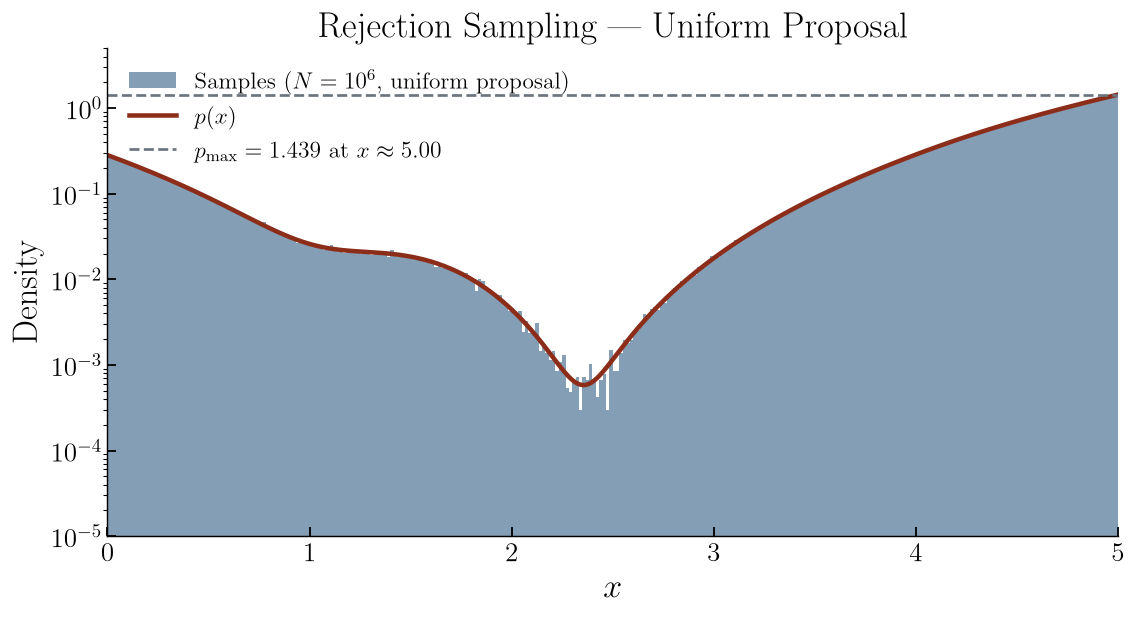

In [3]:
# 6.3 a,b: compute p0 and uniform-proposal rejection sampling

I1, _ = integrate.quad(lambda x: (x - 2)**4, 0, 5)
I2, _ = integrate.quad(lambda x: np.sin(x - 3)**8, 0, 5)
p0 = 1.0 / (I1 + I2)
print(f'I1 = {I1:.6f}  (analytic 55)')
print(f'I2 = {I2:.6f}')
print(f'p0 = {p0:.8f}')

def p63(x):
    return p0 * ((x - 2)**4 + np.sin(x - 3)**8)

norm_check, _ = integrate.quad(p63, 0, 5)
print(f'Normalisation check: {norm_check:.10f}')

x_fine = np.linspace(0, 5, 50_000)
p_vals = p63(x_fine)
p_max  = p_vals.max()
x_pmax = x_fine[p_vals.argmax()]
print(f'\np_max = {p_max:.6f} at x = {x_pmax:.3f}')
print(f'Expected acceptance rate (uniform): {100.0 / (5.0 * p_max):.2f}%')

rng      = np.random.default_rng(0)
N_target = 1_000_000
N_batch  = int(N_target * 5.0 * p_max * 1.5)
X_prop   = rng.uniform(0.0, 5.0, N_batch)
Y_prop   = rng.uniform(0.0, p_max, N_batch)
accept_b = Y_prop <= p63(X_prop)
samples_b = X_prop[accept_b][:N_target]
rej_rate_b = 1.0 - accept_b.mean()
print(f'Observed rejection rate (uniform): {rej_rate_b * 100:.2f}%')

x_plot = np.linspace(0, 5, 800)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(samples_b, bins=300, density=True,
        color=C_BLUE, alpha=0.55, label=r'Samples ($N=10^6$, uniform proposal)')
ax.plot(x_plot, p63(x_plot), lw=2.5, color=C_ORANGE,
        label=r'$p(x)$')
ax.axhline(p_max, ls='--', lw=1.5, color=C_GRAY,
           label=rf'$p_{{\rm max}}={p_max:.3f}$ at $x\approx{x_pmax:.2f}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.set_xlim(0, 5)
ax.set_ylim(1e-5, 5)
ax.set_title('Rejection Sampling — Uniform Proposal')
ax.legend(fontsize=fontsi - 2, loc='upper left')
ax.tick_params(direction='in', length=5, width=1.0)
plt.tight_layout()
plt.savefig('sheet6_output/rejection_uniform.pdf', bbox_inches='tight')
plt.show()

Envelope area A_tot = 1.4650
Theoretical acceptance rate = 68.26%
Max [p(x) - q(x)] = -0.005561  (must be <= 0)


Observed rejection rate (envelope): 31.72%
Improvement vs uniform: 2.71x lower rejection rate


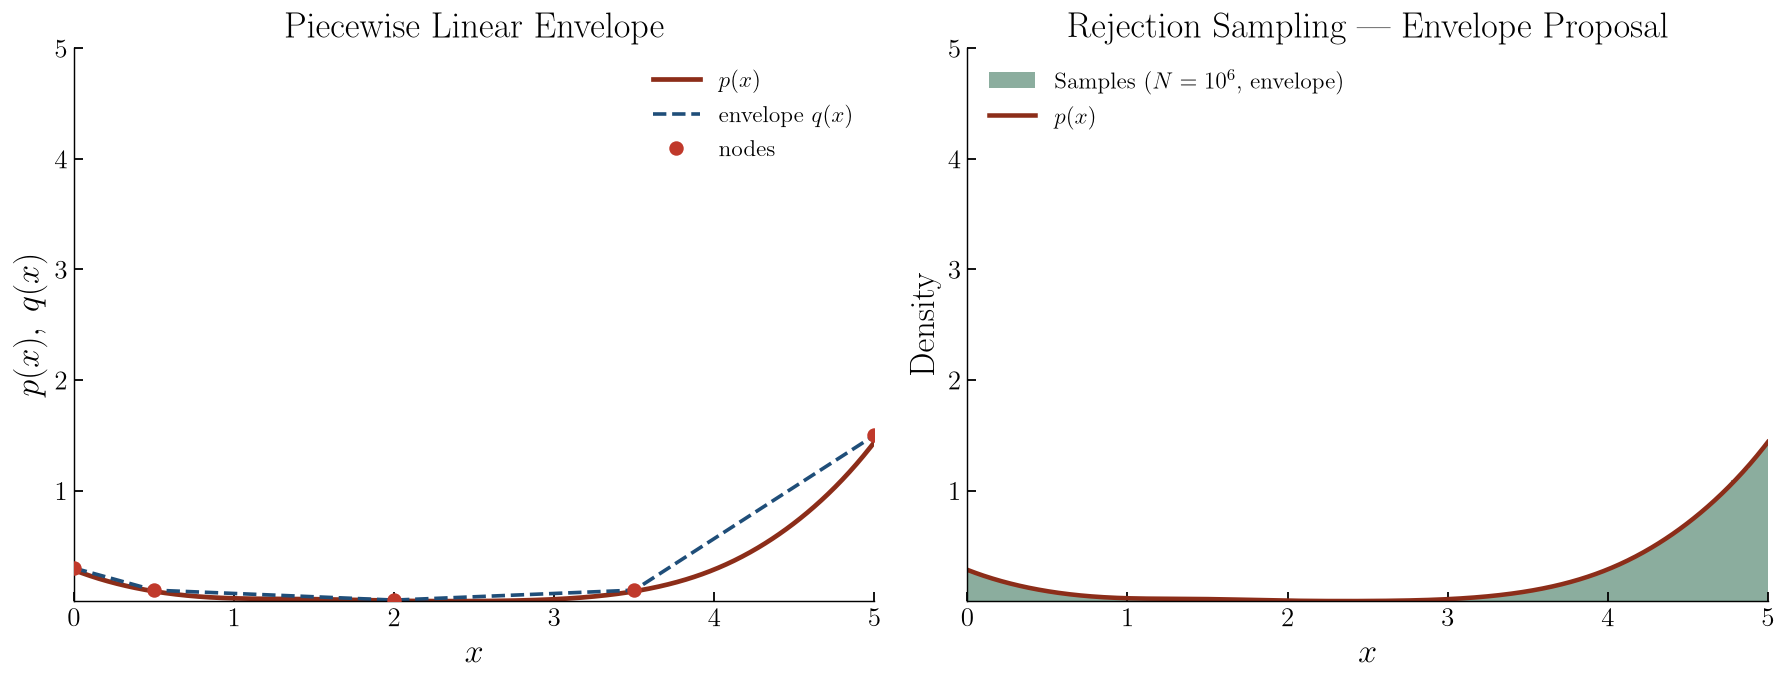

In [4]:
# 6.3 c: piecewise-linear envelope rejection sampling

xn = np.array([0.0,  0.50, 2.00, 3.50, 5.0 ])
yn = np.array([0.30, 0.10, 0.01, 0.10, 1.50])
n_seg  = len(xn) - 1
widths = np.diff(xn)
areas  = 0.5 * (yn[:-1] + yn[1:]) * widths   # trapezoid areas
A_tot  = areas.sum()
seg_probs = areas / A_tot
print(f'Envelope area A_tot = {A_tot:.4f}')
print(f'Theoretical acceptance rate = {100.0 / A_tot:.2f}%')

def q_eval(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    for k in range(n_seg):
        mask = (x >= xn[k]) & (x <= xn[k + 1])
        t = (x[mask] - xn[k]) / widths[k]
        out[mask] = (1 - t) * yn[k] + t * yn[k + 1]
    return out

# Verify q(x) >= p(x) everywhere
x_check   = np.linspace(0, 5, 2_000_000)
violation = (p63(x_check) - q_eval(x_check)).max()
print(f'Max [p(x) - q(x)] = {violation:.6f}  (must be <= 0)')

# Sample from q: choose segment proportionally to area,
# then invert the linear CDF within the segment.
def sample_from_q(n, rng_):
    seg_idx = rng_.choice(n_seg, size=n, p=seg_probs)
    u_seg   = rng_.uniform(0.0, 1.0, n)
    samples = np.empty(n)
    for k in range(n_seg):
        mask = seg_idx == k
        if not mask.any():
            continue
        a  = yn[k]
        b  = (yn[k + 1] - yn[k]) / widths[k]
        uk = u_seg[mask]
        if abs(b) < 1e-14:          # constant segment
            t = uk * widths[k]
        else:
            # invert F_k(t) = (a*t + b*t^2/2) / area_k = u
            disc = a**2 + 2.0 * b * uk * areas[k]
            t    = (-a + np.sqrt(np.maximum(disc, 0.0))) / b
        samples[mask] = xn[k] + t
    return samples

rng2     = np.random.default_rng(1)
N_prop_c = int(N_target * A_tot * 1.5)
X_q      = sample_from_q(N_prop_c, rng2)
u_acc    = rng2.uniform(0.0, 1.0, N_prop_c)
ratio    = np.clip(p63(X_q) / q_eval(X_q), 0.0, 1.0)
accept_c = u_acc <= ratio
samples_c = X_q[accept_c][:N_target]
rej_rate_c = 1.0 - accept_c.mean()
print(f'Observed rejection rate (envelope): {rej_rate_c * 100:.2f}%')
print(f'Improvement vs uniform: {rej_rate_b / rej_rate_c:.2f}x lower rejection rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot(x_plot, p63(x_plot), lw=2.6,
            color=C_ORANGE, label=r'$p(x)$')
ax.plot(x_plot, q_eval(x_plot), lw=2.0, color=C_BLUE, ls='--',
            label=r'envelope $q(x)$')
ax.plot(xn, yn, 'o', color=C_RED, ms=7, zorder=5, label='nodes')
ax.set_xlim(0, 5)
ax.set_ylim(1e-3, 5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$p(x),\;q(x)$')
ax.set_title('Piecewise Linear Envelope')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)

ax2 = axes[1]
ax2.hist(samples_c, bins=300, density=True,
         color=C_GREEN, alpha=0.55, label=r'Samples ($N=10^6$, envelope)')
ax2.plot(x_plot, p63(x_plot), lw=2.5,
         color=C_ORANGE, label=r'$p(x)$')
ax2.set_xlabel(r'$x$')
ax2.set_ylabel('Density')
#ax2.set_yscale('log')
ax2.set_xlim(0, 5)
ax2.set_ylim(1e-5, 5)
ax2.set_title('Rejection Sampling — Envelope Proposal')
ax2.legend(fontsize=fontsi - 2, loc='upper left')
ax2.tick_params(direction='in', length=5, width=1.0)

plt.tight_layout()
plt.savefig('sheet6_output/rejection_envelope.pdf', bbox_inches='tight')
plt.show()

# 6.4  Simulation-Based Inference (SBI)

In many physical models the likelihood $p(\boldsymbol{x}\mid\boldsymbol{\theta})$
is **intractable** — the forward model can be simulated but not evaluated.
**Simulation-Based Inference** (SBI, also called likelihood-free or implicit
likelihood inference) bypasses the likelihood entirely: a neural network is trained
on $(\boldsymbol{\theta}, \boldsymbol{x})$ pairs drawn from the joint prior predictive
$p(\boldsymbol{\theta})\,p(\boldsymbol{x}\mid\boldsymbol{\theta})$, and returns
an amortised approximation $q_\phi(\boldsymbol{\theta}\mid\boldsymbol{x})$ of the
posterior.

Here we use the `sbi` package (Cranmer, Brehmer & Louppe 2020) and study a
2-parameter Gaussian toy problem whose **exact posterior is known analytically**,
so every approximation can be validated.

| Setting | What it controls |
|:---|:---|
| `num_simulations` | simulation budget (accuracy vs cost) |
| `num_transforms` | depth of the normalising flow (expressiveness) |
| `hidden_features` | width of each flow layer |
| Sequential rounds | focus simulations on the posterior region |

**Forward model.**  Parameters $\boldsymbol{\theta}=(\mu,\log\sigma)$,
uniform prior on $[-3,3]\times[-1,1.5]$.  The simulator draws
$N=8$ i.i.d.\ observations from $\mathcal{N}(\mu,\sigma^2)$ and returns the
**sufficient statistics** $\boldsymbol{x}=(\bar x, s)$ (sample mean and std).
Because $(\bar x, s)$ are sufficient, the approximate posterior must converge to
the exact one as the simulation budget increases.


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import warnings
warnings.filterwarnings('ignore')

from sbi import utils as sbi_utils
from sbi.inference import SNPE, SNLE
from sbi.utils.user_input_checks import process_prior, process_simulator
from sbi.utils.simulation_utils import simulate_for_sbi
from sbi.neural_nets import posterior_nn

torch.manual_seed(0)

# -- Forward model ------------------------------------------------------------
N_OBS = 8                           # observations per simulated dataset
THETA_TRUE = np.array([0.8, np.log(0.5)])  # (mu, log_sigma); true sigma = 0.5

prior = sbi_utils.BoxUniform(
    low=torch.tensor([-3.0, -1.0]),
    high=torch.tensor([ 3.0,  1.5]),
)
prior_p, _, _ = process_prior(prior)

_rng_sim = np.random.default_rng(seed=0)   # shared simulator rng

def simulator(theta):
    'Draw N observations from N(mu, sigma^2), return (x_bar, s).'
    mu, ls = float(theta[0]), float(theta[1])
    d = _rng_sim.normal(mu, np.exp(ls), N_OBS)
    return np.array([d.mean(), d.std(ddof=1)], dtype=np.float32)

sim_w = process_simulator(simulator, prior_p, is_numpy_simulator=True)

# -- Observed data (fixed seed, single realisation) ---------------------------
_rng_obs = np.random.default_rng(seed=7)
_d_obs   = _rng_obs.normal(THETA_TRUE[0], np.exp(THETA_TRUE[1]), N_OBS)
X_OBS    = np.array([_d_obs.mean(), _d_obs.std(ddof=1)], dtype=np.float32)
x_obs_t  = torch.tensor(X_OBS).unsqueeze(0)

print(f'True theta:     mu = {THETA_TRUE[0]:.2f},  sigma = {np.exp(THETA_TRUE[1]):.2f}')
print(f'Observed data:  N  = {N_OBS} draws from N({THETA_TRUE[0]}, {np.exp(THETA_TRUE[1])**2:.2f})')
print(f'Summary stats:  x_bar = {X_OBS[0]:.4f},  s = {X_OBS[1]:.4f}')


True theta:     mu = 0.80,  sigma = 0.50
Observed data:  N  = 8 draws from N(0.8, 0.25)
Summary stats:  x_bar = 0.7431,  s = 0.3705


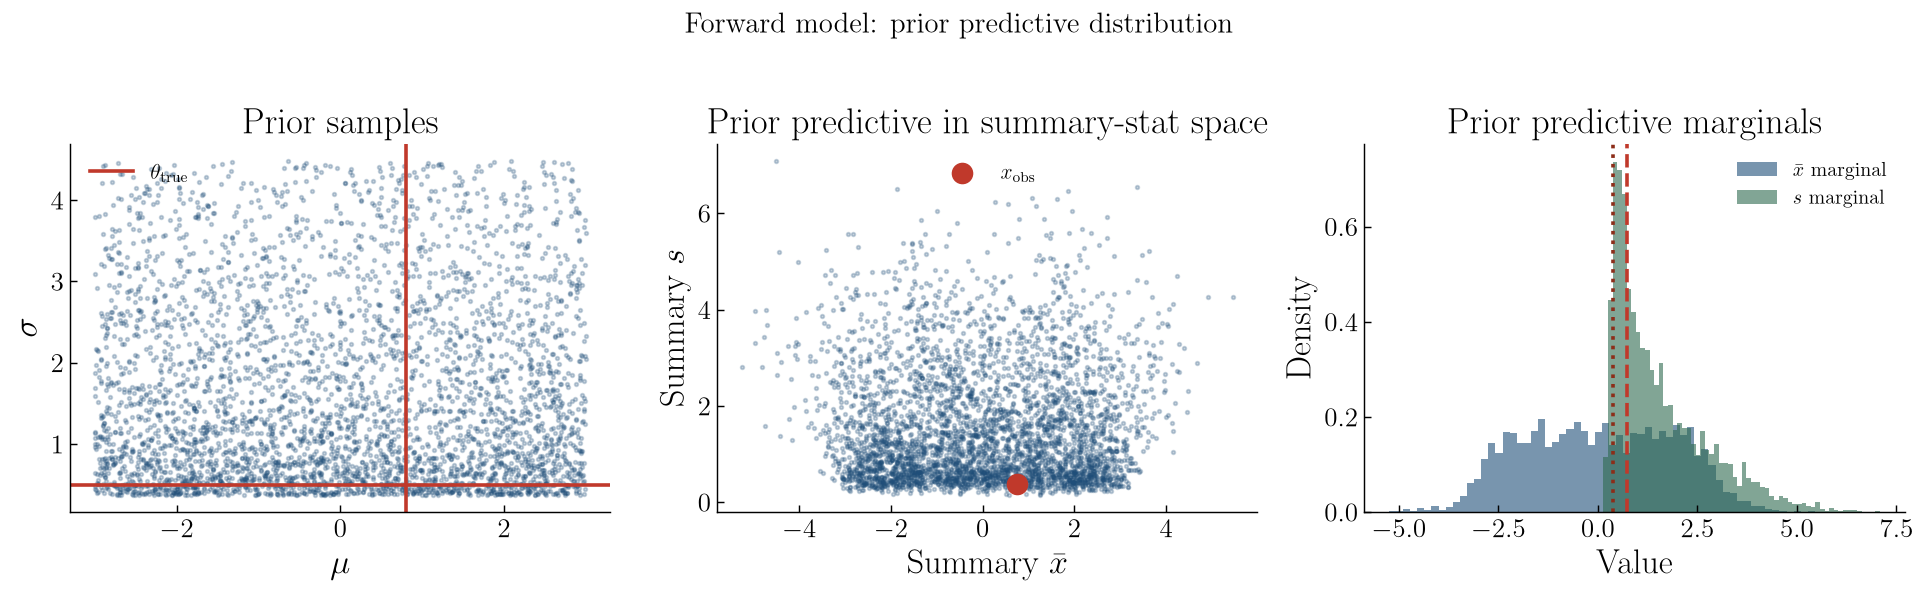

In [6]:
# -- Prior predictive distribution: what does the simulator produce? ----------
N_PRIOR = 4000
theta_pp, x_pp = simulate_for_sbi(sim_w, prior_p, N_PRIOR, show_progress_bar=False)
theta_pp_np = theta_pp.numpy()
x_pp_np     = x_pp.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: prior samples in (mu, sigma) space
ax = axes[0]
ax.scatter(theta_pp_np[:, 0], np.exp(theta_pp_np[:, 1]),
           s=4, alpha=0.25, c='#1f4e79', rasterized=True)
ax.axvline(THETA_TRUE[0], color='#c0392b', lw=2, label=r'$\theta_{\rm true}$')
ax.axhline(np.exp(THETA_TRUE[1]), color='#c0392b', lw=2)
ax.set_xlabel(r'$\mu$'); ax.set_ylabel(r'$\sigma$')
ax.set_title('Prior samples')
ax.legend(fontsize=12)

# Middle: prior predictive in summary-stat space
ax = axes[1]
ax.scatter(x_pp_np[:, 0], x_pp_np[:, 1],
           s=4, alpha=0.25, c='#1f4e79', rasterized=True)
ax.scatter(*X_OBS, s=120, c='#c0392b', zorder=5,
           label=r'$x_{\rm obs}$')
ax.set_xlabel(r'Summary $\bar{x}$')
ax.set_ylabel(r'Summary $s$')
ax.set_title('Prior predictive in summary-stat space')
ax.legend(fontsize=12)

# Right: marginal distributions of x_bar and s
ax = axes[2]
ax.hist(x_pp_np[:, 0], bins=60, density=True, alpha=0.6,
        color='#1f4e79', label=r'$\bar x$ marginal')
ax.hist(x_pp_np[:, 1], bins=60, density=True, alpha=0.6,
        color='#2d6a4f', label=r'$s$ marginal')
ax.axvline(X_OBS[0], color='#c0392b', lw=2, ls='--')
ax.axvline(X_OBS[1], color='#8c2d19', lw=2, ls=':')
ax.set_xlabel('Value'); ax.set_ylabel('Density')
ax.set_title('Prior predictive marginals')
ax.legend(fontsize=11)

for ax in axes:
    ax.tick_params(direction='in', length=4)

plt.suptitle('Forward model: prior predictive distribution', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('summary_output/sbi_prior_predictive.pdf', bbox_inches='tight')
plt.show()


## Analytical reference posterior

For this Gaussian model the summary statistics $(\bar x, s)$ are **sufficient**,
so the exact posterior based on the full data equals the posterior based on
$(\bar x, s)$.  The two factors are independent:

$$\bar x \mid \mu,\sigma \;\sim\; \mathcal{N}\!\left(\mu,\,\frac{\sigma^2}{N}\right),
\qquad
\frac{(N-1)\,s^2}{\sigma^2}\;\sim\;\chi^2_{N-1}\;\text{ independent of }\mu.$$

Evaluating $\ln p(\mu,\log\sigma\mid\bar x_{\rm obs},s_{\rm obs})$ on a 2D grid
gives the exact reference to compare all SBI approximations against.


MAP:  mu = 0.753,  log_sigma = -1.000  (sigma = 0.368)
True: mu = 0.800,  log_sigma = -0.693


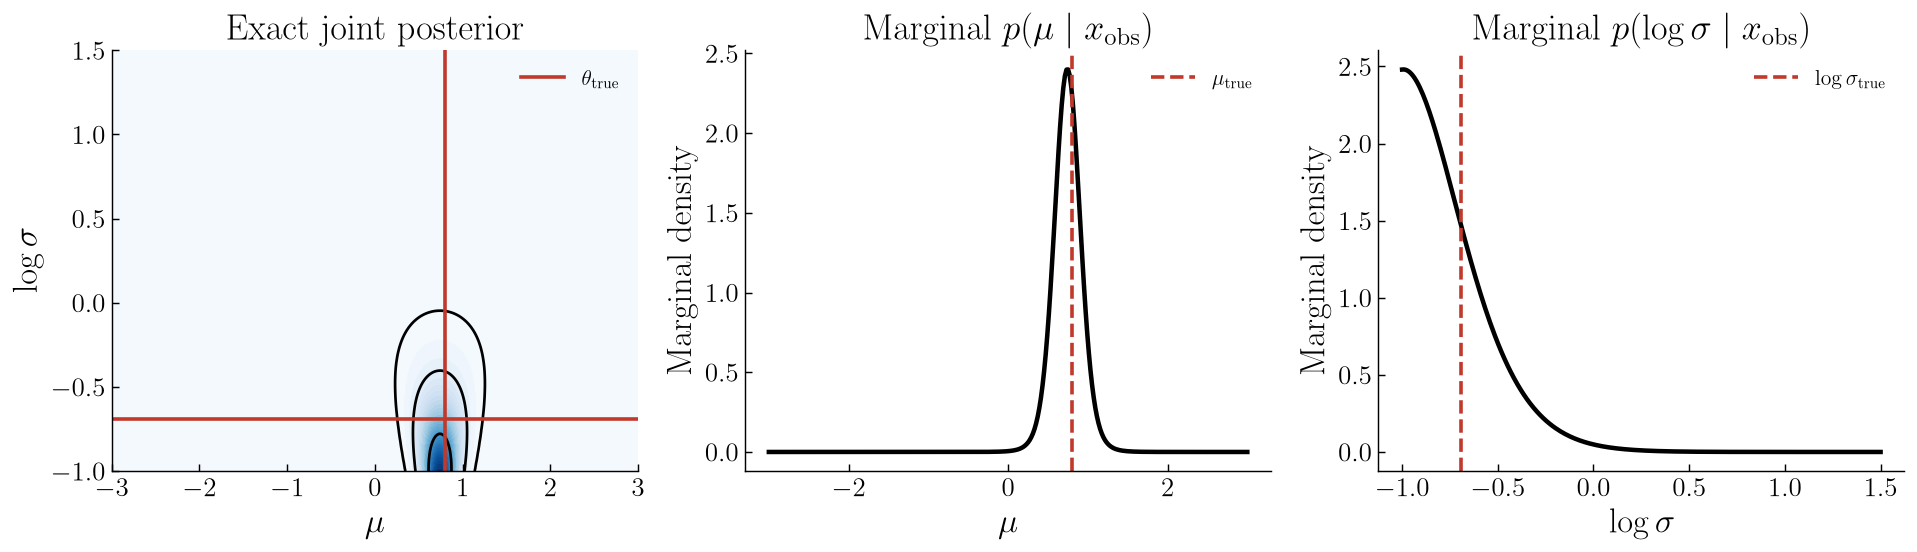

In [7]:
# -- Exact posterior on a 2D grid in (mu, log_sigma) -------------------------
MU_G  = np.linspace(-3.0,  3.0, 300)
LS_G  = np.linspace(-1.0,  1.5, 300)
MU_2D, LS_2D = np.meshgrid(MU_G, LS_G)
SIG_2D = np.exp(LS_2D)

# log p(x_bar | mu, sigma)
lp_xbar = scipy.stats.norm.logpdf(X_OBS[0], loc=MU_2D,
                                   scale=SIG_2D / np.sqrt(N_OBS))

# log p(s | sigma) via chi distribution on t = s*sqrt(N-1)/sigma
t_obs = X_OBS[1] * np.sqrt(N_OBS - 1) / SIG_2D
lp_s  = (scipy.stats.chi.logpdf(t_obs, df=N_OBS - 1)
         + np.log(np.sqrt(N_OBS - 1) / SIG_2D))

# Posterior (uniform prior over the grid range)
log_post_ref = lp_xbar + lp_s
log_post_ref -= log_post_ref.max()
post_ref      = np.exp(log_post_ref)

# Normalise
dmu = MU_G[1] - MU_G[0]
dls = LS_G[1] - LS_G[0]
post_ref /= post_ref.sum() * dmu * dls

# 1D marginals
marg_mu_ref  = post_ref.sum(axis=0) * dls
marg_ls_ref  = post_ref.sum(axis=1) * dmu

# MAP
ii, jj = np.unravel_index(post_ref.argmax(), post_ref.shape)
MAP_MU = MU_G[jj]; MAP_LS = LS_G[ii]
print(f'MAP:  mu = {MAP_MU:.3f},  log_sigma = {MAP_LS:.3f}  (sigma = {np.exp(MAP_LS):.3f})')
print(f'True: mu = {THETA_TRUE[0]:.3f},  log_sigma = {THETA_TRUE[1]:.3f}')

# Convenience: plot reference posteriors on axes
def plot_ref(ax_2d, ax_mu, ax_ls, alpha=1.0, lw=2):
    'Overlay analytical reference contours and 1-D marginals on axes.'
    levels = np.exp([-4.6, -2.3, -0.5])          # 3, 2, 1 sigma (approx)
    ax_2d.contour(MU_G, LS_G, post_ref / post_ref.max(),
                  levels=levels, colors='k', linewidths=lw, alpha=alpha,
                  linestyles=[':', '--', '-'])
    ax_mu.plot(MU_G, marg_mu_ref, 'k-', lw=lw, alpha=alpha, label='Exact')
    ax_ls.plot(LS_G, marg_ls_ref, 'k-', lw=lw, alpha=alpha)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.contourf(MU_G, LS_G, post_ref, levels=30, cmap='Blues')
ax.contour(MU_G, LS_G, post_ref / post_ref.max(),
           levels=np.exp([-4.6, -2.3, -0.5]), colors='k', linewidths=1.5)
ax.axvline(THETA_TRUE[0], color='#c0392b', lw=2, label=r'$\theta_{\rm true}$')
ax.axhline(THETA_TRUE[1], color='#c0392b', lw=2)
ax.set_xlabel(r'$\mu$'); ax.set_ylabel(r'$\log\sigma$')
ax.set_title('Exact joint posterior'); ax.legend(fontsize=12)

axes[1].plot(MU_G, marg_mu_ref, 'k-', lw=2.5)
axes[1].axvline(THETA_TRUE[0], color='#c0392b', lw=2, ls='--',
               label=r'$\mu_{\rm true}$')
axes[1].set_xlabel(r'$\mu$'); axes[1].set_ylabel('Marginal density')
axes[1].set_title(r'Marginal $p(\mu\mid x_{\rm obs})$'); axes[1].legend(fontsize=12)

axes[2].plot(LS_G, marg_ls_ref, 'k-', lw=2.5)
axes[2].axvline(THETA_TRUE[1], color='#c0392b', lw=2, ls='--',
               label=r'$\log\sigma_{\rm true}$')
axes[2].set_xlabel(r'$\log\sigma$'); axes[2].set_ylabel('Marginal density')
axes[2].set_title(r'Marginal $p(\log\sigma\mid x_{\rm obs})$'); axes[2].legend(fontsize=12)

for ax in axes:
    ax.tick_params(direction='in', length=4)
plt.tight_layout()
plt.savefig('summary_output/sbi_exact_posterior.pdf', bbox_inches='tight')
plt.show()


## SNPE — Sequential Neural Posterior Estimation

**SNPE** (Papamakarios & Murray 2016; Lueckmann et al.\ 2017; Greenberg et al.\ 2019)
trains a **normalising flow** $q_\phi(\boldsymbol{\theta}\mid\boldsymbol{x})$ to
approximate the posterior by minimising the KL divergence
$\mathrm{KL}[p(\boldsymbol{\theta}\mid\boldsymbol{x})\,\|\,q_\phi(\boldsymbol{\theta}\mid\boldsymbol{x})]$
over simulations drawn from the joint prior predictive.

The flow used here is a **Neural Spline Flow** (NSF; Durkan et al.\ 2019):
a composition of rational-quadratic spline transformations, each conditioned on
$\boldsymbol{x}$ via a neural network embedding.  Key architecture hyperparameters:

* `num_transforms` — depth (number of spline layers)
* `hidden_features` — width of each conditioner network


 Training neural network. Epochs trained: 3

 Training neural network. Epochs trained: 6

 Training neural network. Epochs trained: 9

 Training neural network. Epochs trained: 11

 Training neural network. Epochs trained: 15

...

 Training neural network. Epochs trained: 54

 Training neural network. Epochs trained: 58

 Training neural network. Epochs trained: 60

 Training neural network. Epochs trained: 64

 Neural network successfully converged after 67 epochs.SNPE (3000 sims):
  mu         = 0.728 +/- 0.472  (true 0.80)
  sigma      = 0.534 +/- 0.111  (true 0.50)


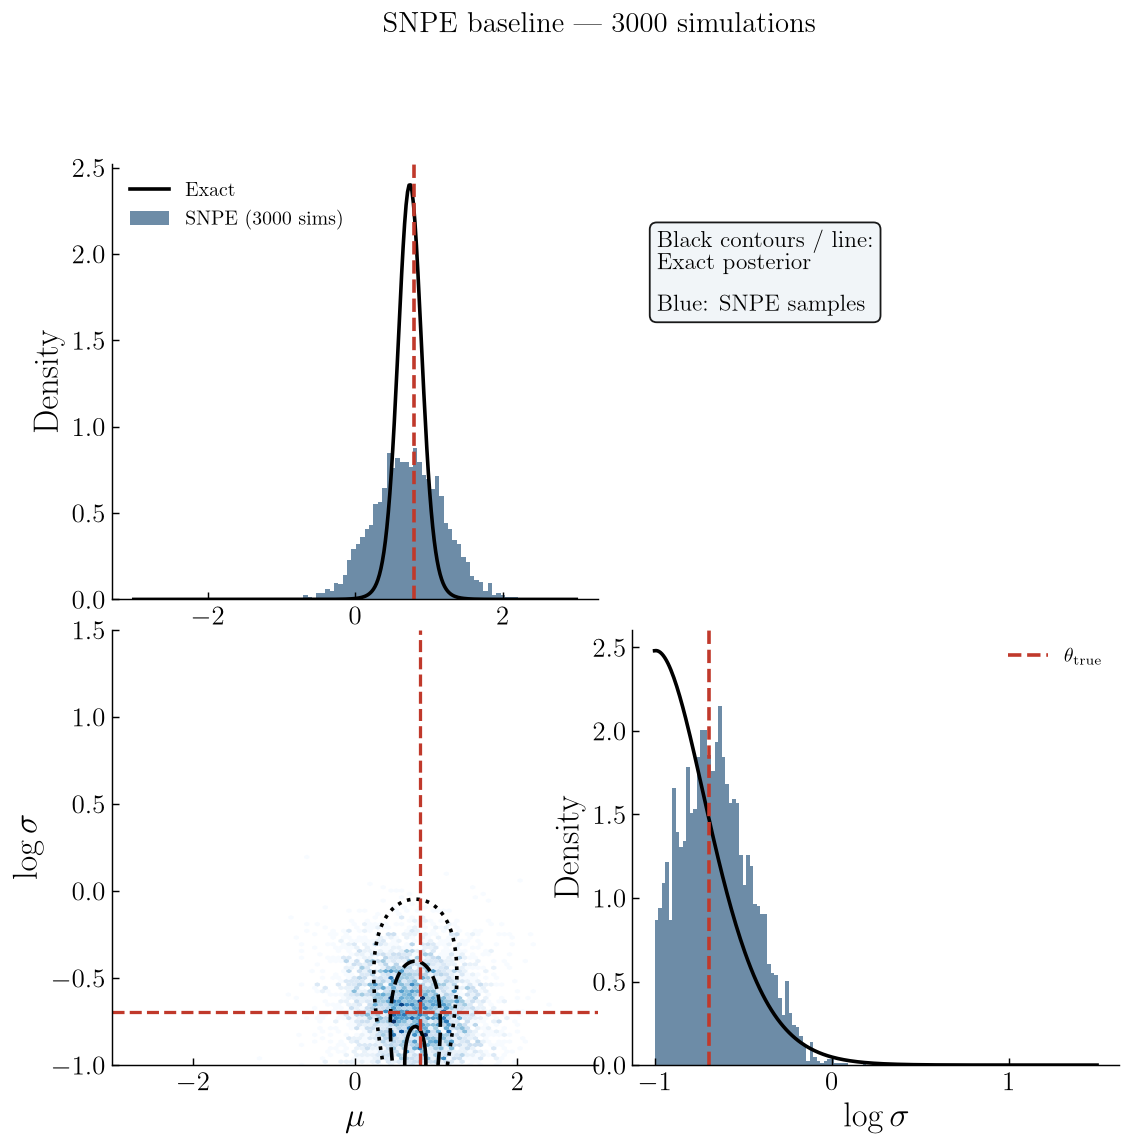

In [8]:
# -- SNPE with 3000 simulations (default NSF architecture) --------------------
N_TRAIN_BASE = 3000
N_SAMPLES    = 4000

torch.manual_seed(1)
_rng_sim.bit_generator.state = np.random.default_rng(1).bit_generator.state

theta_tr, x_tr = simulate_for_sbi(sim_w, prior_p, N_TRAIN_BASE,
                                   show_progress_bar=False)

snpe_base = SNPE(prior=prior_p)
snpe_base.append_simulations(theta_tr, x_tr)
_ = snpe_base.train(show_train_summary=False)
post_base = snpe_base.build_posterior()

samples_base = post_base.sample((N_SAMPLES,), x=x_obs_t,
                                show_progress_bars=False).numpy()

mu_samp  = samples_base[:, 0]
ls_samp  = samples_base[:, 1]

print(f'SNPE ({N_TRAIN_BASE} sims):')
print(f'  mu         = {mu_samp.mean():.3f} +/- {mu_samp.std():.3f}  '
      f'(true {THETA_TRUE[0]:.2f})')
print(f'  sigma      = {np.exp(ls_samp).mean():.3f} +/- {np.exp(ls_samp).std():.3f}  '
      f'(true {np.exp(THETA_TRUE[1]):.2f})')

# -- Corner plot: SNPE samples vs exact posterior -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 9),
                          gridspec_kw={'hspace': 0.07, 'wspace': 0.07})

ax2d = axes[1, 0]
ax2d.hexbin(mu_samp, ls_samp, gridsize=55, cmap='Blues', mincnt=1, linewidths=0)
plot_ref(ax2d, axes[0, 0], axes[1, 1])
ax2d.axvline(THETA_TRUE[0], color='#c0392b', lw=1.8, ls='--')
ax2d.axhline(THETA_TRUE[1], color='#c0392b', lw=1.8, ls='--')
ax2d.set_xlabel(r'$\mu$'); ax2d.set_ylabel(r'$\log\sigma$')

axes[0, 0].hist(mu_samp, bins=60, density=True, color='#1f4e79', alpha=0.65,
                label=f'SNPE ({N_TRAIN_BASE} sims)')
axes[0, 0].axvline(THETA_TRUE[0], color='#c0392b', lw=2, ls='--')
axes[0, 0].set_ylabel('Density'); axes[0, 0].set_xlabel(r'$\mu$')
axes[0, 0].legend(fontsize=11)

axes[1, 1].hist(ls_samp, bins=60, density=True, color='#1f4e79', alpha=0.65)
axes[1, 1].axvline(THETA_TRUE[1], color='#c0392b', lw=2, ls='--',
                   label=r'$\theta_{\rm true}$')
axes[1, 1].set_xlabel(r'$\log\sigma$'); axes[1, 1].set_ylabel('Density')
axes[1, 1].legend(fontsize=11)

axes[0, 1].axis('off')
axes[0, 1].text(0.05, 0.85,
    'Black contours / line:\nExact posterior\n\n'
    'Blue: SNPE samples',
    transform=axes[0, 1].transAxes, va='top', fontsize=13,
    bbox=dict(boxstyle='round', fc='#f0f4f8', alpha=0.9))

for ax in [ax2d, axes[0,0], axes[1,1]]:
    ax.tick_params(direction='in', length=4)

plt.suptitle(f'SNPE baseline — {N_TRAIN_BASE} simulations', y=1.01, fontsize=16)
plt.tight_layout()
plt.savefig('summary_output/sbi_snpe_base.pdf', bbox_inches='tight')
plt.show()


## Effect of simulation budget

With too few simulations the flow undertrains and the posterior is broad or
biased.  As the budget grows, $q_\phi \to p(\boldsymbol{\theta}\mid\boldsymbol{x})$.
The key question is: **how many simulations are enough for the posterior to
converge to the exact one?**


 Training neural network. Epochs trained: 23

 Training neural network. Epochs trained: 53

 Training neural network. Epochs trained: 82

 Training neural network. Epochs trained: 111

 Training neural network. Epochs trained: 134

...

 Training neural network. Epochs trained: 76

 Training neural network. Epochs trained: 79

 Training neural network. Epochs trained: 82

 Training neural network. Epochs trained: 85

 Neural network successfully converged after 86 epochs. 5000 sims:  mu = 0.754 +/- 0.191


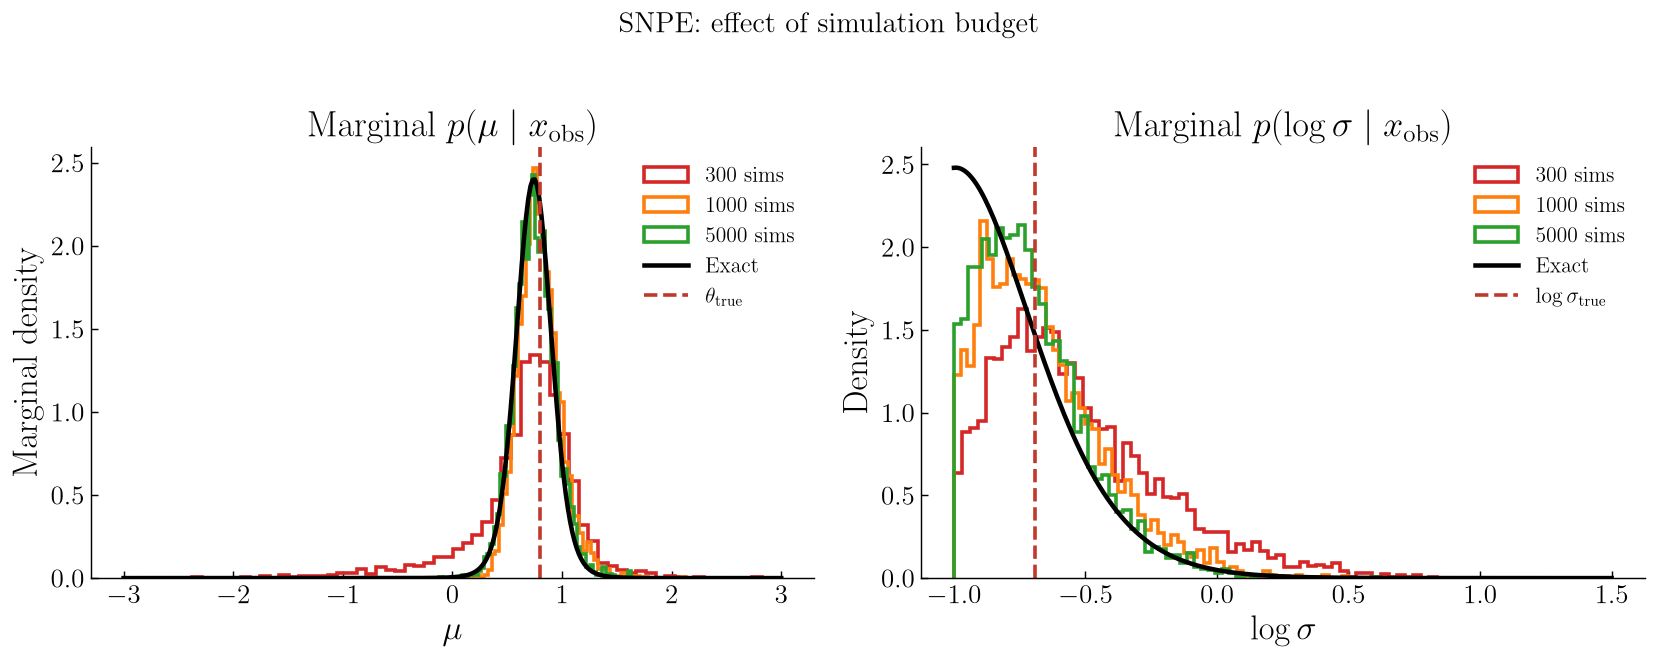

In [9]:
# -- Train SNPE for three simulation budgets -----------------------------------
BUDGETS = [300, 1000, 5000]
COLORS  = ['#d62728', '#ff7f0e', '#2ca02c']
LABELS  = [f'{n} sims' for n in BUDGETS]

budget_samples = {}
for n_sim, col in zip(BUDGETS, COLORS):
    torch.manual_seed(42)
    th_b, x_b = simulate_for_sbi(sim_w, prior_p, n_sim, show_progress_bar=False)
    snpe_b = SNPE(prior=prior_p)
    snpe_b.append_simulations(th_b, x_b).train(show_train_summary=False)
    post_b = snpe_b.build_posterior()
    budget_samples[n_sim] = post_b.sample((N_SAMPLES,), x=x_obs_t,
                                           show_progress_bars=False).numpy()
    mu_b = budget_samples[n_sim][:, 0]
    print(f'{n_sim:>5} sims:  mu = {mu_b.mean():.3f} +/- {mu_b.std():.3f}')

# -- Overlaid marginals vs exact ----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for n_sim, col, lab in zip(BUDGETS, COLORS, LABELS):
    s = budget_samples[n_sim]
    axes[0].hist(s[:, 0], bins=60, density=True, histtype='step',
                 color=col, lw=2, label=lab)
    axes[1].hist(s[:, 1], bins=60, density=True, histtype='step',
                 color=col, lw=2)

axes[0].plot(MU_G, marg_mu_ref, 'k-', lw=2.5, label='Exact')
axes[1].plot(LS_G, marg_ls_ref, 'k-', lw=2.5, label='Exact')

for ax in axes:
    ax.axvline(THETA_TRUE[axes.tolist().index(ax)], color='#c0392b',
               lw=2, ls='--', label=r'$\theta_{\rm true}$')
    ax.tick_params(direction='in', length=4)

axes[0].set_xlabel(r'$\mu$'); axes[0].set_ylabel('Marginal density')
axes[0].set_title(r'Marginal $p(\mu\mid x_{\rm obs})$')
axes[0].legend(fontsize=12)

axes[1].set_xlabel(r'$\log\sigma$')
axes[1].set_title(r'Marginal $p(\log\sigma\mid x_{\rm obs})$')
# Manually set true-theta vline for log_sigma panel
axes[1].get_lines()[-1].set_xdata([THETA_TRUE[1], THETA_TRUE[1]])

# Redo log_sigma panel cleanly
axes[1].clear()
for n_sim, col in zip(BUDGETS, COLORS):
    axes[1].hist(budget_samples[n_sim][:, 1], bins=60, density=True,
                 histtype='step', color=col, lw=2, label=f'{n_sim} sims')
axes[1].plot(LS_G, marg_ls_ref, 'k-', lw=2.5, label='Exact')
axes[1].axvline(THETA_TRUE[1], color='#c0392b', lw=2, ls='--',
               label=r'$\log\sigma_{\rm true}$')
axes[1].set_xlabel(r'$\log\sigma$'); axes[1].set_ylabel('Density')
axes[1].set_title(r'Marginal $p(\log\sigma\mid x_{\rm obs})$')
axes[1].legend(fontsize=12)
axes[1].tick_params(direction='in', length=4)

plt.suptitle('SNPE: effect of simulation budget', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('summary_output/sbi_budget_comparison.pdf', bbox_inches='tight')
plt.show()


## Flow architecture hyperparameters

The **Neural Spline Flow** is characterised by two main hyperparameters:

* **`num_transforms`** (depth): number of spline coupling layers.
  Each layer applies a learnable invertible transformation to a subset of
  the parameters, conditioned on the complementary subset.  More layers
  increase expressiveness but also training cost.

* **`hidden_features`** (width): number of neurons in each conditioner
  network.  Wider networks can learn more complex conditioning but risk
  overfitting with a small simulation budget.

We compare three settings at a fixed budget of 2 000 simulations and plot
the training / validation loss alongside the resulting posteriors.


 Training neural network. Epochs trained: 6

 Training neural network. Epochs trained: 12

 Training neural network. Epochs trained: 18

 Training neural network. Epochs trained: 24

 Training neural network. Epochs trained: 30

...

 Training neural network. Epochs trained: 38

 Training neural network. Epochs trained: 40

 Training neural network. Epochs trained: 42

 Training neural network. Epochs trained: 44

 Neural network successfully converged after 45 epochs.NSF(8t, 128h):  epochs=45,  mu=0.748+/-0.233


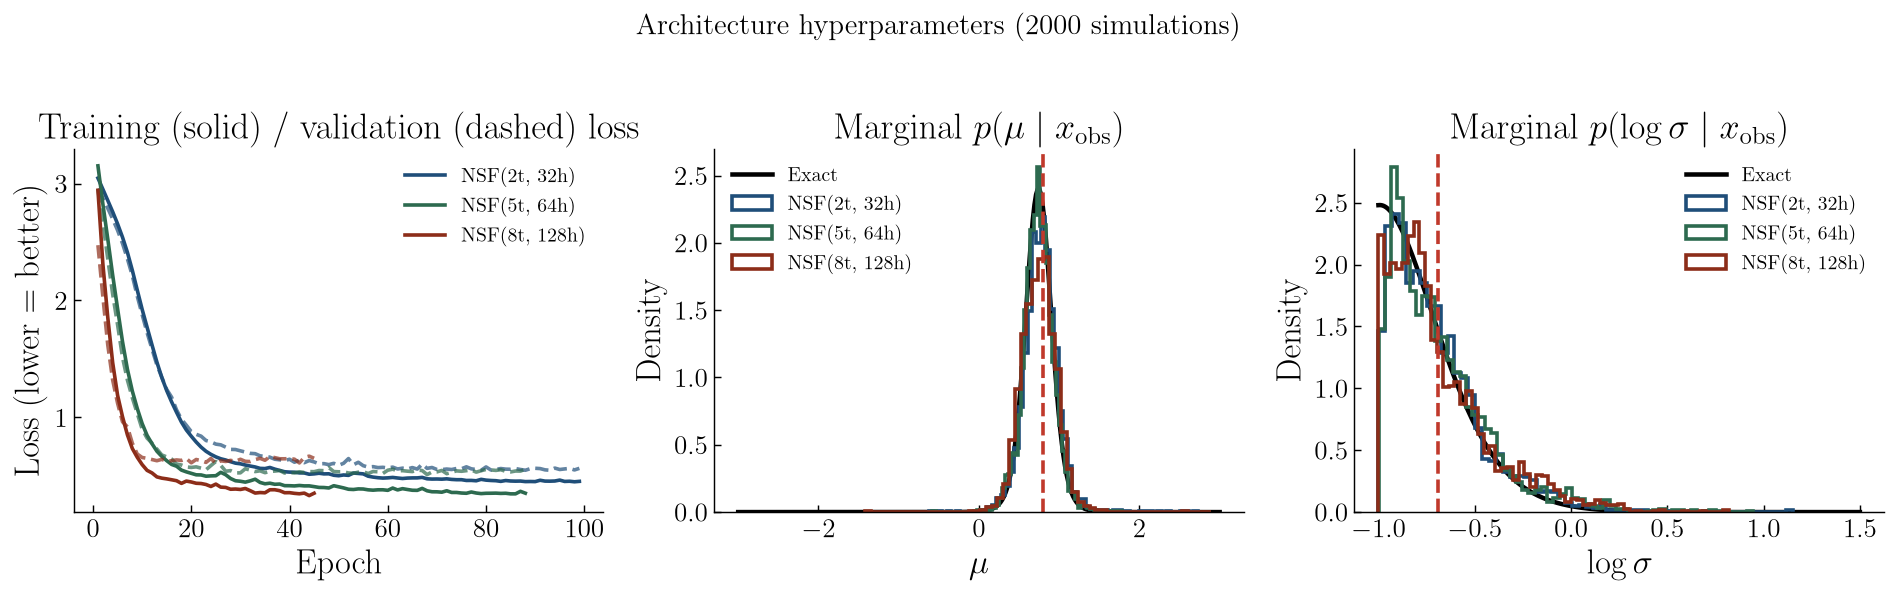

In [10]:
# -- Architecture comparison: num_transforms x hidden_features ----------------
ARCHITECTURES = [
    (2,  32,  '#1f4e79', 'NSF(2t, 32h)'),
    (5,  64,  '#2d6a4f', 'NSF(5t, 64h)'),
    (8, 128,  '#8c2d19', 'NSF(8t, 128h)'),
]
N_ARCH = 2000

torch.manual_seed(10)
th_a, x_a = simulate_for_sbi(sim_w, prior_p, N_ARCH, show_progress_bar=False)

arch_results = {}
for n_tr, n_hid, col, label in ARCHITECTURES:
    flow = posterior_nn(model='nsf', num_transforms=n_tr, hidden_features=n_hid)
    snpe_a = SNPE(prior=prior_p, density_estimator=flow)
    snpe_a.append_simulations(th_a, x_a)
    _ = snpe_a.train(show_train_summary=False)

    # Extract training and validation losses from summary
    summary = snpe_a._summary
    train_loss = np.array(summary['training_loss'])
    val_loss   = np.array(summary['validation_loss'])

    post_a = snpe_a.build_posterior()
    samp_a = post_a.sample((N_SAMPLES,), x=x_obs_t,
                            show_progress_bars=False).numpy()
    arch_results[label] = {
        'samples': samp_a, 'col': col,
        'train_loss': train_loss, 'val_loss': val_loss,
    }
    print(f'{label}:  epochs={len(train_loss)},  '
          f'mu={samp_a[:,0].mean():.3f}+/-{samp_a[:,0].std():.3f}')

# -- Loss curves ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
for label, res in arch_results.items():
    ep = np.arange(1, len(res['train_loss']) + 1)
    ax.plot(ep, res['train_loss'], color=res['col'], lw=2,    label=label)
    ax.plot(ep, res['val_loss'],   color=res['col'], lw=2,
            ls='--', alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (lower = better)')
ax.set_title('Training (solid) / validation (dashed) loss')
ax.legend(fontsize=11); ax.tick_params(direction='in', length=4)

# -- Marginal mu ---------------------------------------------------------------
ax = axes[1]
ax.plot(MU_G, marg_mu_ref, 'k-', lw=2.5, label='Exact')
for label, res in arch_results.items():
    ax.hist(res['samples'][:, 0], bins=60, density=True,
            histtype='step', color=res['col'], lw=2, label=label)
ax.axvline(THETA_TRUE[0], color='#c0392b', lw=2, ls='--')
ax.set_xlabel(r'$\mu$'); ax.set_ylabel('Density')
ax.set_title(r'Marginal $p(\mu\mid x_{\rm obs})$')
ax.legend(fontsize=11); ax.tick_params(direction='in', length=4)

# -- Marginal log_sigma --------------------------------------------------------
ax = axes[2]
ax.plot(LS_G, marg_ls_ref, 'k-', lw=2.5, label='Exact')
for label, res in arch_results.items():
    ax.hist(res['samples'][:, 1], bins=60, density=True,
            histtype='step', color=res['col'], lw=2, label=label)
ax.axvline(THETA_TRUE[1], color='#c0392b', lw=2, ls='--')
ax.set_xlabel(r'$\log\sigma$'); ax.set_ylabel('Density')
ax.set_title(r'Marginal $p(\log\sigma\mid x_{\rm obs})$')
ax.legend(fontsize=11); ax.tick_params(direction='in', length=4)

plt.suptitle(f'Architecture hyperparameters ({N_ARCH} simulations)', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('summary_output/sbi_architecture.pdf', bbox_inches='tight')
plt.show()


## Sequential SNPE (SNPE-C / APT)

**Amortised** SNPE draws from the prior $p(\boldsymbol{\theta})$: every
simulation is useful for any future observation, but many simulations fall far
from the posterior.

**Sequential** SNPE (Greenberg et al.\ 2019, APT / SNPE-C) refines the
proposal distribution round by round, focusing simulations on the posterior
region of $\boldsymbol{x}_{\rm obs}$.  At each round the current posterior
estimate becomes the proposal for the next round.

With a limited total simulation budget, sequential SNPE can substantially
outperform amortised SNPE because it wastes fewer simulations on prior regions
that are ruled out by the data.  Here we compare

| Method | Rounds | Sims per round | Total sims |
|:---|:---:|:---:|:---:|
| Amortised SNPE | 1 | 1 500 | 1 500 |
| Sequential SNPE | 3 | 500 | 1 500 |

The prior spans $\mu\in[-3,3]$ (width 6) while the posterior on $\mu$ has
width $\sim\sigma/\sqrt{N}\approx 0.18$ — a factor $\approx 33$ narrower.
Sequential SNPE exploits this by focussing budget where it matters.


 Training neural network. Epochs trained: 9

 Training neural network. Epochs trained: 18

 Training neural network. Epochs trained: 27

 Training neural network. Epochs trained: 36

 Training neural network. Epochs trained: 41

...

 Training neural network. Epochs trained: 14

 Training neural network. Epochs trained: 15

 Training neural network. Epochs trained: 17

 Training neural network. Epochs trained: 18

 Neural network successfully converged after 20 epochs.Round 3: mu = 0.756 +/- 0.3367  (N_eff_sims = 1500)


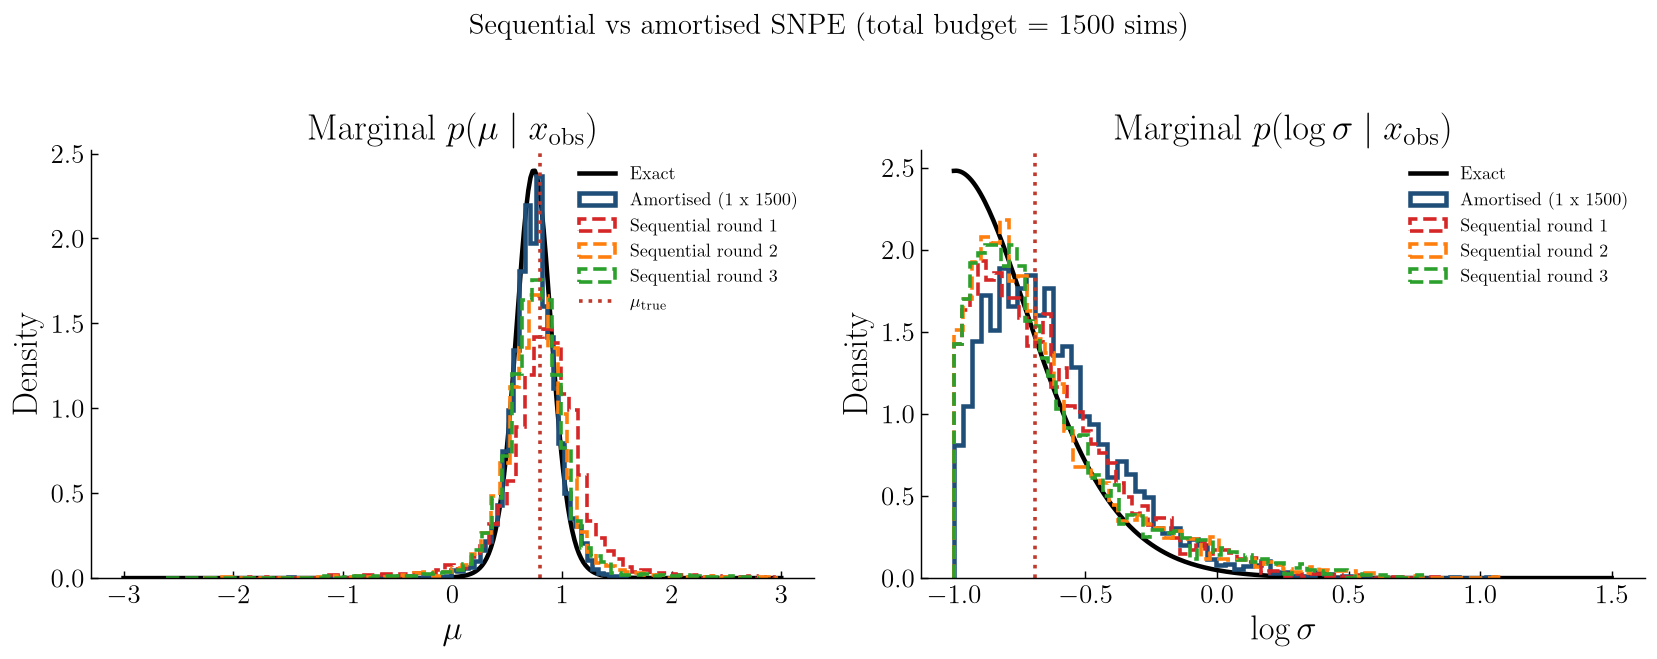

In [11]:
# -- Amortised vs sequential SNPE (same total budget) -------------------------
N_TOTAL  = 1500
N_ROUNDS = 3
N_PER_ROUND = N_TOTAL // N_ROUNDS   # 500 per round

# ---- Amortised (1 round) ----
torch.manual_seed(20)
th_am, x_am = simulate_for_sbi(sim_w, prior_p, N_TOTAL, show_progress_bar=False)
snpe_am = SNPE(prior=prior_p)
snpe_am.append_simulations(th_am, x_am).train(show_train_summary=False)
post_am = snpe_am.build_posterior()
samp_am = post_am.sample((N_SAMPLES,), x=x_obs_t, show_progress_bars=False).numpy()

# ---- Sequential (3 rounds) ----
torch.manual_seed(30)
snpe_seq = SNPE(prior=prior_p)
proposal  = prior_p
round_posteriors = []

for r in range(N_ROUNDS):
    th_r, x_r = simulate_for_sbi(sim_w, proposal, N_PER_ROUND,
                                  show_progress_bar=False)
    snpe_seq.append_simulations(th_r, x_r, proposal=proposal).train(
        show_train_summary=False)
    post_r = snpe_seq.build_posterior()
    round_posteriors.append(
        post_r.sample((N_SAMPLES,), x=x_obs_t, show_progress_bars=False).numpy()
    )
    proposal = post_r.set_default_x(x_obs_t)
    mu_r = round_posteriors[-1][:, 0]
    print(f'Round {r+1}: mu = {mu_r.mean():.3f} +/- {mu_r.std():.4f}  '
          f'(N_eff_sims = {(r+1)*N_PER_ROUND})')

samp_seq = round_posteriors[-1]   # final round posterior

# -- Comparison plot -----------------------------------------------------------
SEQ_COLORS = ['#d62728', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(MU_G, marg_mu_ref, 'k-', lw=2.5, label='Exact')
ax.hist(samp_am[:, 0], bins=60, density=True, histtype='step',
        color='#1f4e79', lw=2.5, label=f'Amortised (1 x {N_TOTAL})')
for ri, (samp_r, col) in enumerate(zip(round_posteriors, SEQ_COLORS)):
    ax.hist(samp_r[:, 0], bins=60, density=True, histtype='step',
            color=col, lw=2, ls='--',
            label=f'Sequential round {ri+1}')
ax.axvline(THETA_TRUE[0], color='#c0392b', lw=2, ls=':',
           label=r'$\mu_{\rm true}$')
ax.set_xlabel(r'$\mu$'); ax.set_ylabel('Density')
ax.set_title(r'Marginal $p(\mu\mid x_{\rm obs})$')
ax.legend(fontsize=10); ax.tick_params(direction='in', length=4)

ax = axes[1]
ax.plot(LS_G, marg_ls_ref, 'k-', lw=2.5, label='Exact')
ax.hist(samp_am[:, 1], bins=60, density=True, histtype='step',
        color='#1f4e79', lw=2.5, label=f'Amortised (1 x {N_TOTAL})')
for ri, (samp_r, col) in enumerate(zip(round_posteriors, SEQ_COLORS)):
    ax.hist(samp_r[:, 1], bins=60, density=True, histtype='step',
            color=col, lw=2, ls='--',
            label=f'Sequential round {ri+1}')
ax.axvline(THETA_TRUE[1], color='#c0392b', lw=2, ls=':')
ax.set_xlabel(r'$\log\sigma$'); ax.set_ylabel('Density')
ax.set_title(r'Marginal $p(\log\sigma\mid x_{\rm obs})$')
ax.legend(fontsize=10); ax.tick_params(direction='in', length=4)

plt.suptitle(
    f'Sequential vs amortised SNPE  (total budget = {N_TOTAL} sims)',
    y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('summary_output/sbi_sequential.pdf', bbox_inches='tight')
plt.show()


In [12]:
# -- Summary: posterior means and stds for all settings -----------------------
print('=' * 65)
print('  SBI HYPERPARAMETER SUMMARY')
print(f'  True: mu = {THETA_TRUE[0]:.2f},  sigma = {np.exp(THETA_TRUE[1]):.2f}')
print('=' * 65)
print(f'{"Setting":<28} {"mu":>8} {"sig_mu":>8} {"sigma":>8} {"sig_s":>8}')
print('-' * 65)

rows = [
    ('Exact posterior',   samples_base[:,0]*0 + np.nan, None, None),
    ('SNPE 300  sims',    budget_samples[300],    None, None),
    ('SNPE 1000 sims',    budget_samples[1000],   None, None),
    ('SNPE 3000 sims (base)', samples_base,        None, None),
    ('SNPE 5000 sims',    budget_samples[5000],   None, None),
]
for label, res in arch_results.items():
    rows.append((label, res['samples'], None, None))
rows.append(('Amortised (1x1500)',   samp_am,  None, None))
rows.append(('Sequential (3x500)',   samp_seq, None, None))

all_sets = {
    'Exact (MAP)':          np.array([[MAP_MU, MAP_LS]]),
    'SNPE 300':             budget_samples[300],
    'SNPE 1000':            budget_samples[1000],
    'SNPE 3000 (base)':     samples_base,
    'SNPE 5000':            budget_samples[5000],
}
for label, res in arch_results.items():
    all_sets[label] = res['samples']
all_sets['Amortised 1x1500'] = samp_am
all_sets['Sequential 3x500'] = samp_seq

for name, samp in all_sets.items():
    if samp.shape[0] == 1:
        print(f'{name:<28} {samp[0,0]:>8.3f} {"—":>8} {np.exp(samp[0,1]):>8.3f} {"—":>8}')
    else:
        print(f'{name:<28} {samp[:,0].mean():>8.3f} {samp[:,0].std():>8.4f} '
              f'{np.exp(samp[:,1]).mean():>8.3f} {np.exp(samp[:,1]).std():>8.4f}')

print('=' * 65)
print(f'{"Ground truth":<28} {THETA_TRUE[0]:>8.3f} {"—":>8} {np.exp(THETA_TRUE[1]):>8.3f} {"—":>8}')


  SBI HYPERPARAMETER SUMMARY
  True: mu = 0.80,  sigma = 0.50
Setting                            mu   sig_mu    sigma    sig_s
-----------------------------------------------------------------
Exact (MAP)                     0.753        —    0.368        —
SNPE 300                        0.662   0.4863    0.619   0.2349
SNPE 1000                       0.798   0.1942    0.530   0.1391
SNPE 3000 (base)                0.728   0.4719    0.534   0.1114
SNPE 5000                       0.754   0.1914    0.507   0.1208
NSF(2t, 32h)                    0.779   0.2236    0.514   0.1578
NSF(5t, 64h)                    0.743   0.1871    0.521   0.1709
NSF(8t, 128h)                   0.748   0.2333    0.522   0.1678
Amortised 1x1500                0.737   0.2173    0.554   0.1673
Sequential 3x500                0.756   0.3367    0.549   0.2083
Ground truth                    0.800        —    0.500        —
